In [ ]:
import sys
sys.path.append("..")

In [ ]:
from DicomToNumpyClass import DicomToNumpy

In [ ]:
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")

In [4]:
processor.generate_files()

Iniciando procesamiento desde: Brain_Stroke_CT_Dataset
Destino: Brain_Stroke_CT_Dataset_numpy

Error leyendo 10187.dcm: Unable to decompress 'JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])' pixel data because all plugins are missing dependencies:
	gdcm - requires gdcm>=3.0.10
	pylibjpeg - requires pylibjpeg>=2.0 and pylibjpeg-libjpeg>=2.1
Error leyendo 10690.dcm: Unable to decompress 'JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])' pixel data because all plugins are missing dependencies:
	gdcm - requires gdcm>=3.0.10
	pylibjpeg - requires pylibjpeg>=2.0 and pylibjpeg-libjpeg>=2.1
Error leyendo 11380.dcm: Unable to decompress 'JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])' pixel data because all plugins are missing dependencies:
	gdcm - requires gdcm>=3.0.10
	pylibjpeg - requires pylibjpeg>=2.0 and pylibjpeg-libjpeg>=2.1
Error leyendo 11956.dcm: Unable to decomp

In [5]:
processor.summary()

--------------------------------------------------
RESUMEN DEL PROCESAMIENTO
--------------------------------------------------
Clase: Bleeding
  - Imágenes guardadas (512x512): 1070
  - Imágenes descartadas (otro tamaño): 23
  - Shape final del array: (1070, 512, 512)
  - Guardado en: Brain_Stroke_CT_Dataset_numpy\Bleeding.npy
..............................
Clase: Ischemia
  - Imágenes guardadas (512x512): 1076
  - Imágenes descartadas (otro tamaño): 40
  - Shape final del array: (1076, 512, 512)
  - Guardado en: Brain_Stroke_CT_Dataset_numpy\Ischemia.npy
..............................
Clase: Normal
  - Imágenes guardadas (512x512): 4242
  - Imágenes descartadas (otro tamaño): 185
  - Shape final del array: (4242, 512, 512)
  - Guardado en: Brain_Stroke_CT_Dataset_numpy\Normal.npy
..............................
TOTAL IMÁGENES PROCESADAS: 6388
--------------------------------------------------


In [3]:
dataset = processor.get_data()

Cargando datos en memoria...
  -> Cargado Bleeding: (1070, 512, 512)
  -> Cargado Ischemia: (1076, 512, 512)
  -> Cargado Normal: (4242, 512, 512)


In [4]:
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes

Cargando subconjunto de datos (Primeras 1000 imágenes)...
  -> Cargado Bleeding: (1000, 512, 512)
  -> Cargado Ischemia: (1000, 512, 512)
  -> Cargado Normal: (1000, 512, 512)


In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def analyze_noise_vs_content(image_array, corner_size=30):
    """
    Compara el histograma de la imagen completa contra el histograma
    del aire (esquinas) para diagnosticar la relación Señal-Ruido.
    """
    h, w = image_array.shape
    
    # 1. Extraer píxeles de las esquinas (Ruido/Aire)
    corners = [
        image_array[0:corner_size, 0:corner_size],           # Arriba-Izq
        image_array[0:corner_size, w-corner_size:w]         # Arriba-Der
        #image_array[h-corner_size:h, 0:corner_size],         # Abajo-Izq
        #image_array[h-corner_size:h, w-corner_size:w]        # Abajo-Der
    ]
    noise_pixels = np.concatenate([c.flatten() for c in corners])
    
    # 2. Extraer píxeles de TODA la imagen
    all_pixels = image_array.flatten()
    
    # Estadísticas
    noise_mean = np.mean(noise_pixels)
    noise_std = np.std(noise_pixels)
    
    # --- VISUALIZACIÓN ---
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # A) IMAGEN con cajas guía
    # Usamos vmin/vmax automáticos para ver contraste
    ax[0].imshow(image_array, cmap='gray')
    ax[0].set_title(f"Std Dev del Aire (Ruido): {noise_std:.2f}")
    ax[0].axis('off')
    
    # Dibujar cajas para confirmar qué estamos midiendo como "Ruido"
    rects = [
        patches.Rectangle((0, 0), corner_size, corner_size, linewidth=2, edgecolor='red', facecolor='none'),
        patches.Rectangle((w-corner_size, 0), corner_size, corner_size, linewidth=2, edgecolor='red', facecolor='none')
        #patches.Rectangle((0, h-corner_size), corner_size, corner_size, linewidth=2, edgecolor='red', facecolor='none'),
        #patches.Rectangle((w-corner_size, h-corner_size), corner_size, corner_size, linewidth=2, edgecolor='red', facecolor='none')
    ]
    for r in rects:
        ax[0].add_patch(r)

    # B) HISTOGRAMA COMPARATIVO
    # 1. Histograma de TODA la imagen (Gris)
    ax[1].hist(all_pixels, bins=100, color='gray', alpha=0.5, label='Toda la Imagen (Anatomía)', log=True)
    
    # 2. Histograma SOLO de las esquinas (Rojo)
    ax[1].hist(noise_pixels, bins=50, color='red', alpha=0.6, label='Solo Esquinas (Aire/Ruido)', log=True)
    
    ax[1].set_title("Comparación: ¿Cuánto se mezcla el ruido con el tejido?")
    ax[1].set_xlabel("Valor del Píxel (Intensidad HU o Raw)")
    ax[1].set_ylabel("Frecuencia (Log)")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

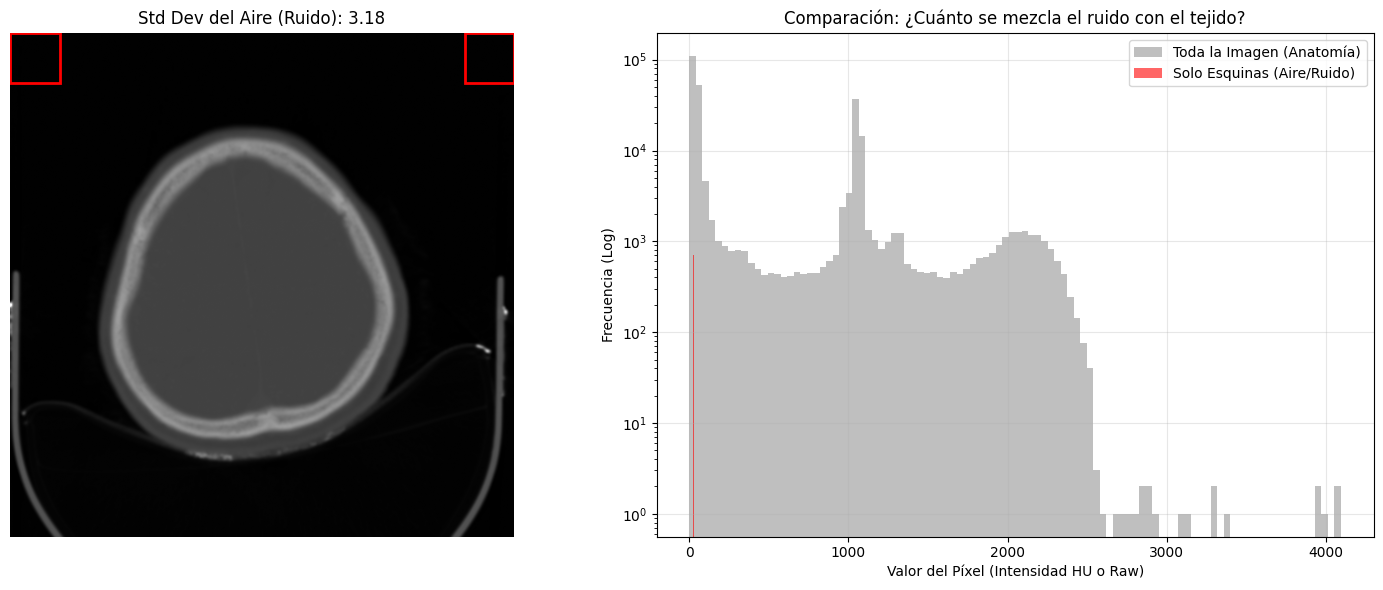

In [117]:
analyze_noise_vs_content(subdataset['Normal'][0], corner_size=50)

In [118]:
import matplotlib.pyplot as plt
import numpy as np

def get_top_left_corner(image_array, size=30, histogram=False):
    """
    Extrae la esquina superior izquierda de una imagen.
    
    Args:
        image_array (np.array): La imagen completa.
        size (int): Tamaño del recorte (px). Por defecto 30x30.
        histogram (bool): Si es True, muestra el histograma del recorte.
        
    Returns:
        np.array: El recorte de la esquina.
    """
    # 1. Extraer el segmento (Slicing básico de Numpy)
    corner_slice = image_array[0:size, 0:size]
    
    # 2. Mostrar Histograma (Solo si se pide)
    if histogram:
        flat_data = corner_slice.flatten()
        
        plt.figure(figsize=(10, 4))
        
        # Subplot 1: Ver qué estamos recortando
        plt.subplot(1, 2, 1)
        plt.imshow(corner_slice, cmap='gray')
        plt.title(f"Recorte ({size}x{size})")
        plt.axis('off')
        
        # Subplot 2: El histograma
        plt.subplot(1, 2, 2)
        # Usamos 'auto' bins para que se ajuste si es un solo valor o ruido
        plt.hist(flat_data, bins='auto', color='red', alpha=0.7)
        plt.title("Distribución de valores en la esquina")
        plt.xlabel("Valor del Píxel")
        plt.ylabel("Frecuencia")
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Info extra en consola para confirmar si es plano
        print(f"--- Estadísticas de la esquina ---")
        print(f"Min: {flat_data.min()}, Max: {flat_data.max()}")
        print(f"Valores únicos encontrados: {np.unique(flat_data)}")

    # 3. Retornar el array
    return corner_slice

In [148]:
import numpy as np
import matplotlib.pyplot as plt

def advanced_background_suppression(image_array, corner_size=30):
    """
    Detecta si es Raw, aplica la separación forzada de fondo y muestra:
    1. Imagen Antes
    2. Imagen Después
    3. Histograma Final (Solo el nuevo)
    """
    
    # Copia para no modificar el original y para comparar después
    img_original = image_array.copy()
    img_processed = image_array.copy().astype(np.float32)
    
    # --- 1. LÓGICA DE PROCESAMIENTO ---
    corner = img_processed[0:corner_size, 0:corner_size]
    mean_air = np.mean(corner)
    
    was_processed = False
    
    # Si el aire es > -500, asumimos que es Raw (ej: 0, 24, 100)
    if mean_air > -500:
        was_processed = True
        
        # A. Detectar rango exacto del aire en la esquina
        min_val_air = np.min(corner)
        max_val_air = np.max(corner)
        
        # Margen de tolerancia (por si hay un píxel perdido de ruido)
        margin = 5
        target_min = min_val_air - margin
        target_max = max_val_air + margin
        
        # B. Crear máscara del aire y castigar con -1000 extra
        mask_air = (img_processed >= target_min) & (img_processed <= target_max)
        img_processed[mask_air] -= 1000
        
        # C. Restar offset global estándar (-1024) a TODO
        img_processed -= 1024
        
        title_status = f"Procesado: Aire Raw ({int(mean_air)}) -> Movido a ~ -2000"
    else:
        title_status = "Sin Cambios: La imagen ya estaba en HU"

    # --- 2. VISUALIZACIÓN ---
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Advanced Background Suppression\n{title_status}", fontsize=14, color='darkblue')

    # A) Imagen Antes
    ax[0].imshow(img_original, cmap='gray')
    ax[0].set_title("1. Imagen Antes (Original)")
    ax[0].axis('off')

    # B) Imagen Después
    # Usamos vmin/vmax para asegurar que el contraste se vea bien (Cerebro)
    ax[1].imshow(img_processed, cmap='gray', vmin=-100, vmax=200)
    ax[1].set_title("2. Imagen Después (Corregida)")
    ax[1].axis('off')

    # C) Histograma Final (SOLO EL NUEVO)
    # Aplanamos la imagen para el histograma
    flat_data = img_processed.flatten()
    
    ax[2].hist(flat_data, bins=100, log=True, color='teal', alpha=0.8)
    ax[2].set_title("3. Nuevo Histograma")
    ax[2].set_xlabel("Unidades Hounsfield (HU)")
    ax[2].set_ylabel("Frecuencia (Log)")
    ax[2].grid(True, alpha=0.3)
    
    # Líneas de referencia para que verifiques tu "Abismo"
    ax[2].axvline(-1000, color='red', linestyle='--', label='Aire Std (-1000)')
    ax[2].axvline(0, color='orange', linestyle=':', label='Agua/Tejido (0)')
    if was_processed:
        # Deberías ver un pico gigante aquí si funcionó tu lógica
        ax[2].axvline(-2000, color='blue', linestyle='--', label='Fondo Forzado (-2000)')
    
    ax[2].legend()

    plt.tight_layout()
    plt.show()
    
    return img_processed

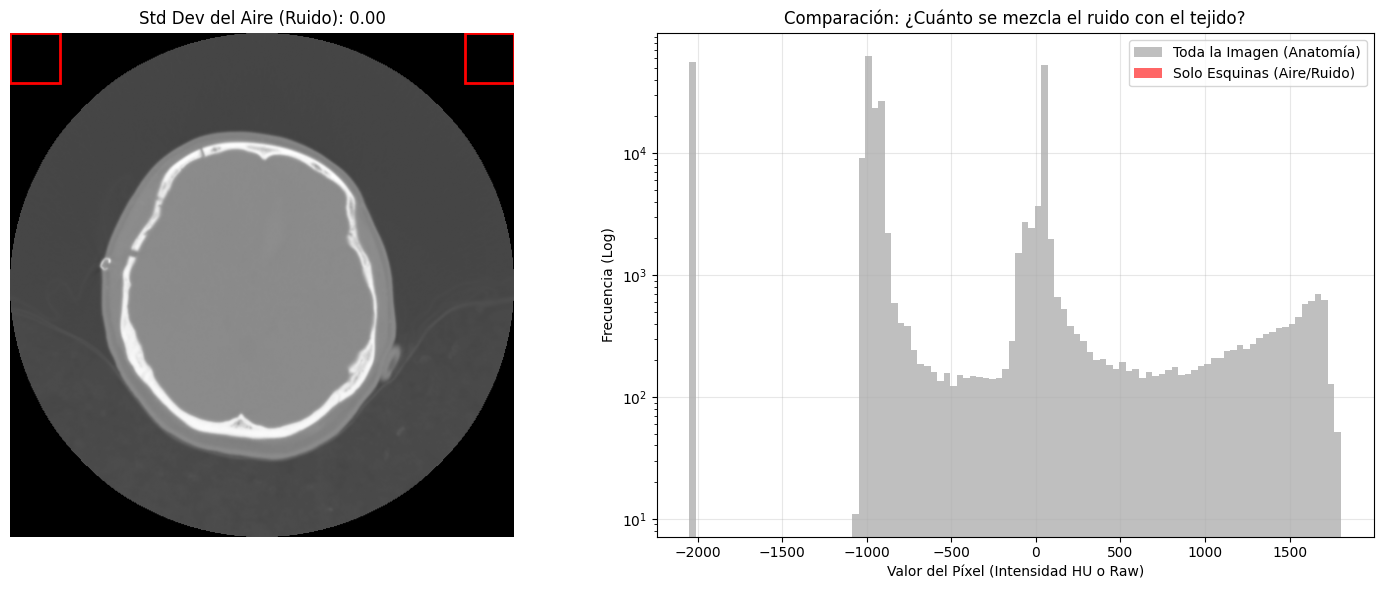

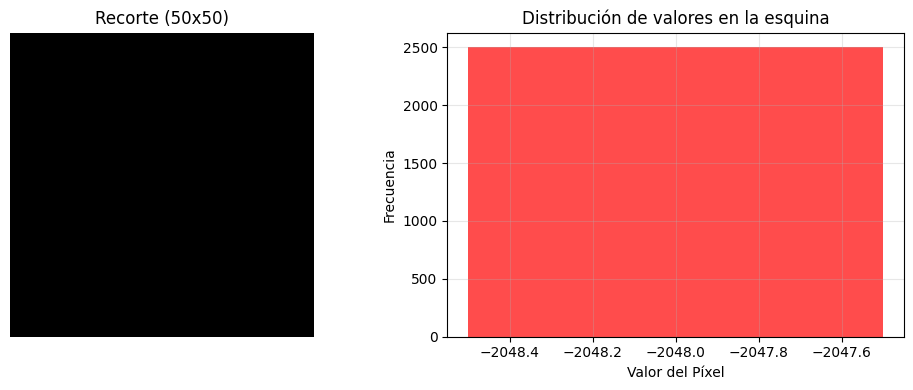

--- Estadísticas de la esquina ---
Min: -2048, Max: -2048
Valores únicos encontrados: [-2048]


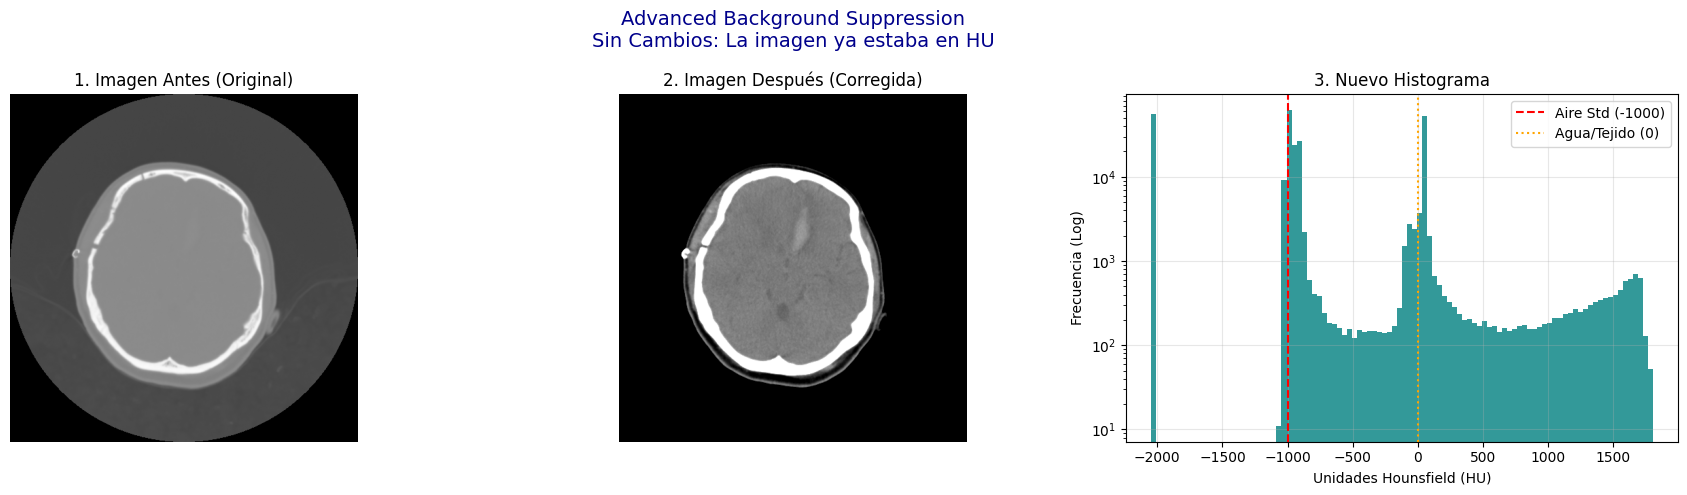

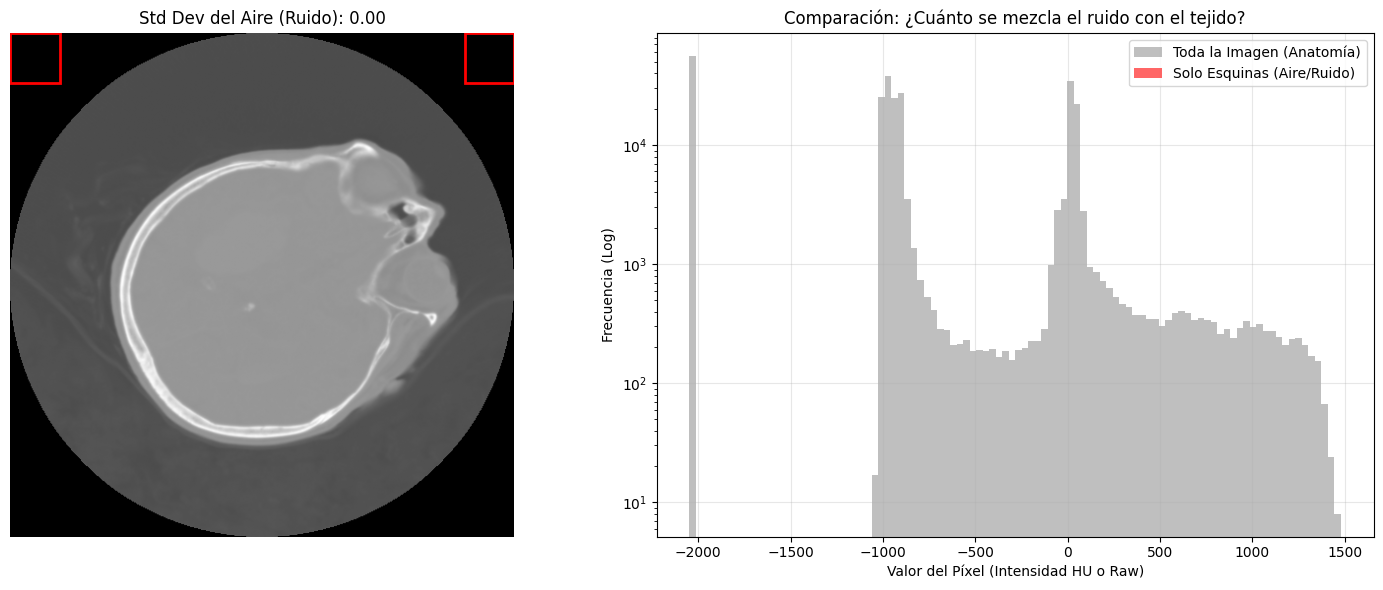

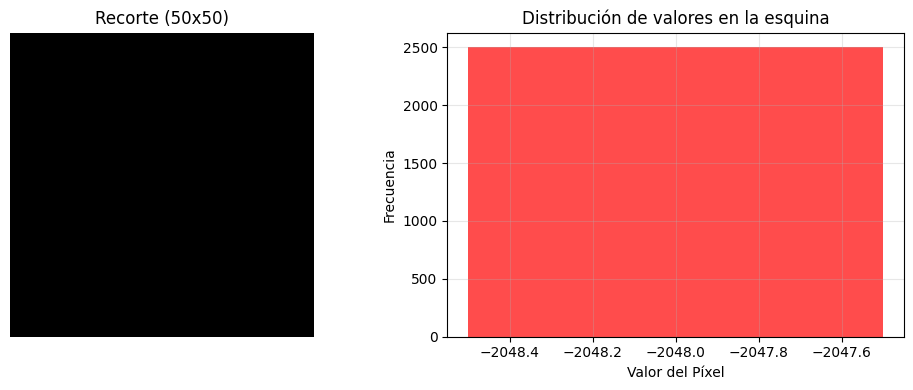

--- Estadísticas de la esquina ---
Min: -2048, Max: -2048
Valores únicos encontrados: [-2048]


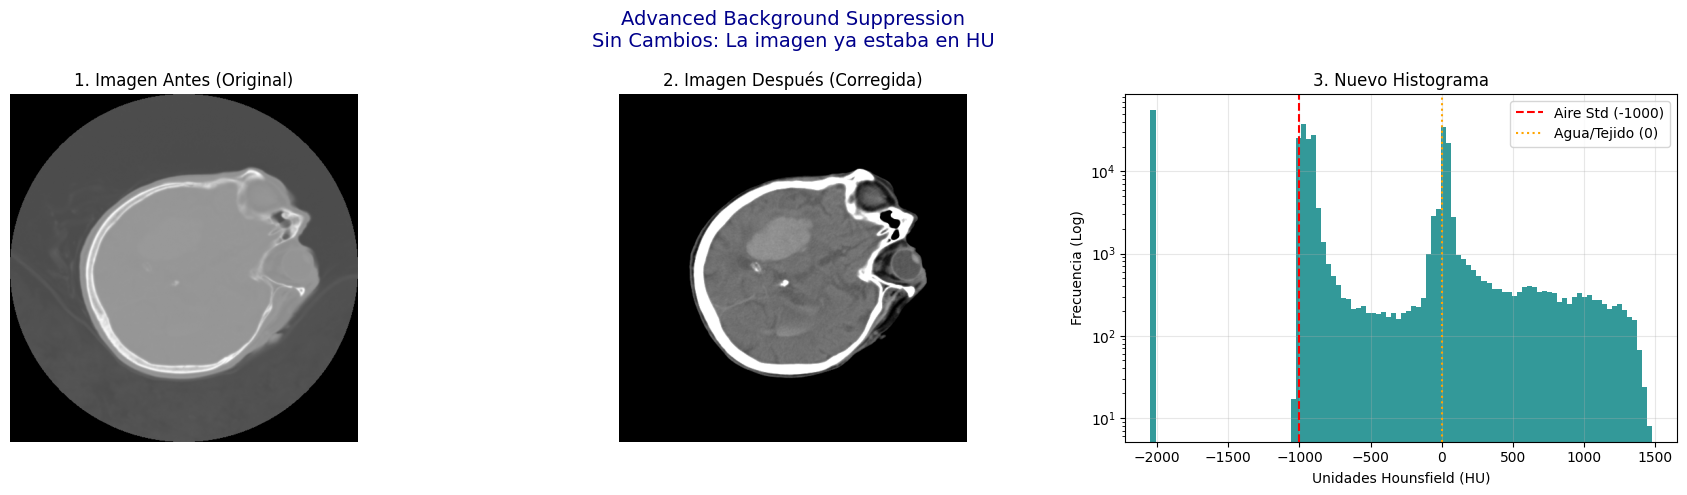

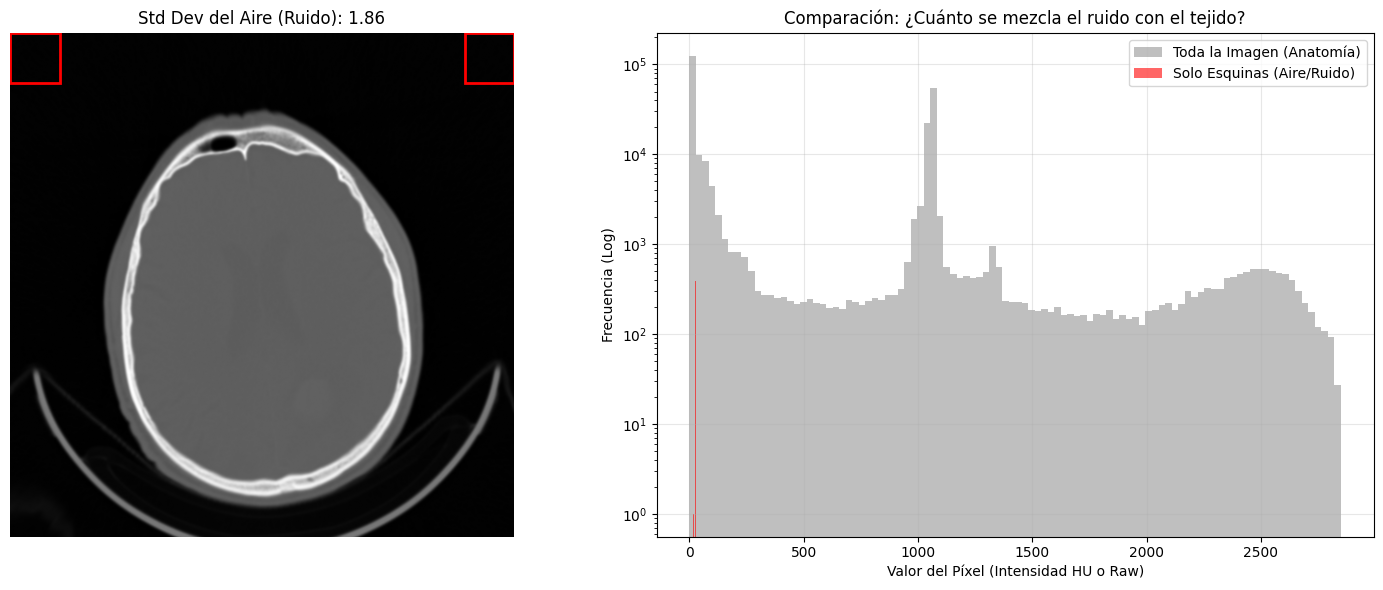

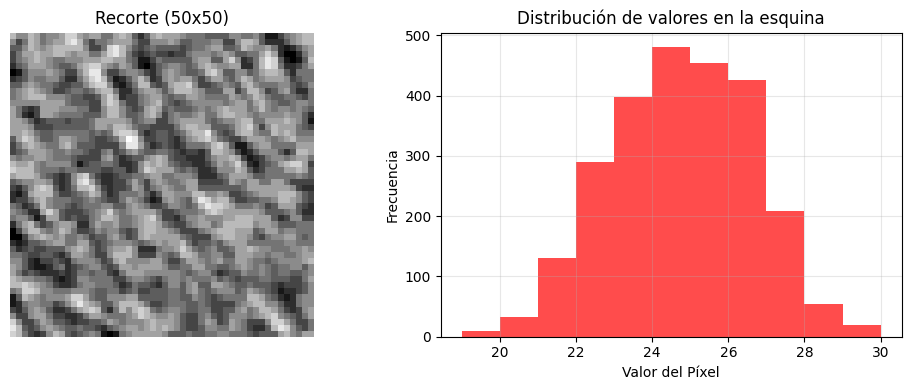

--- Estadísticas de la esquina ---
Min: 19, Max: 30
Valores únicos encontrados: [19 20 21 22 23 24 25 26 27 28 29 30]


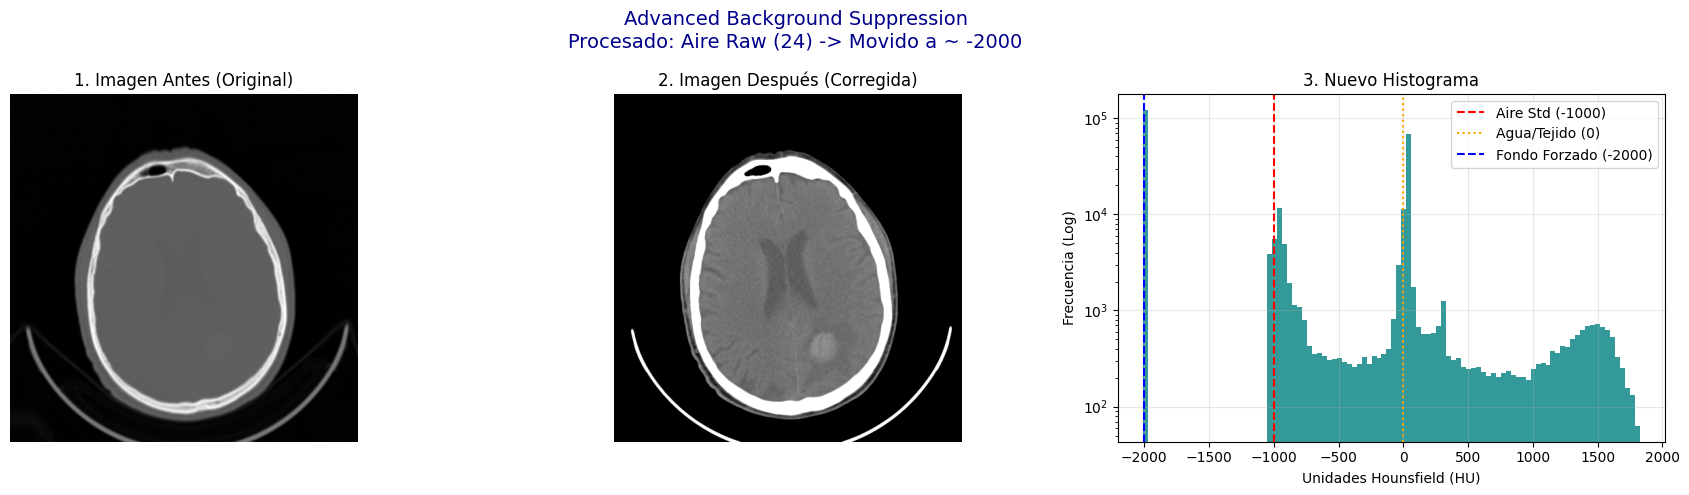

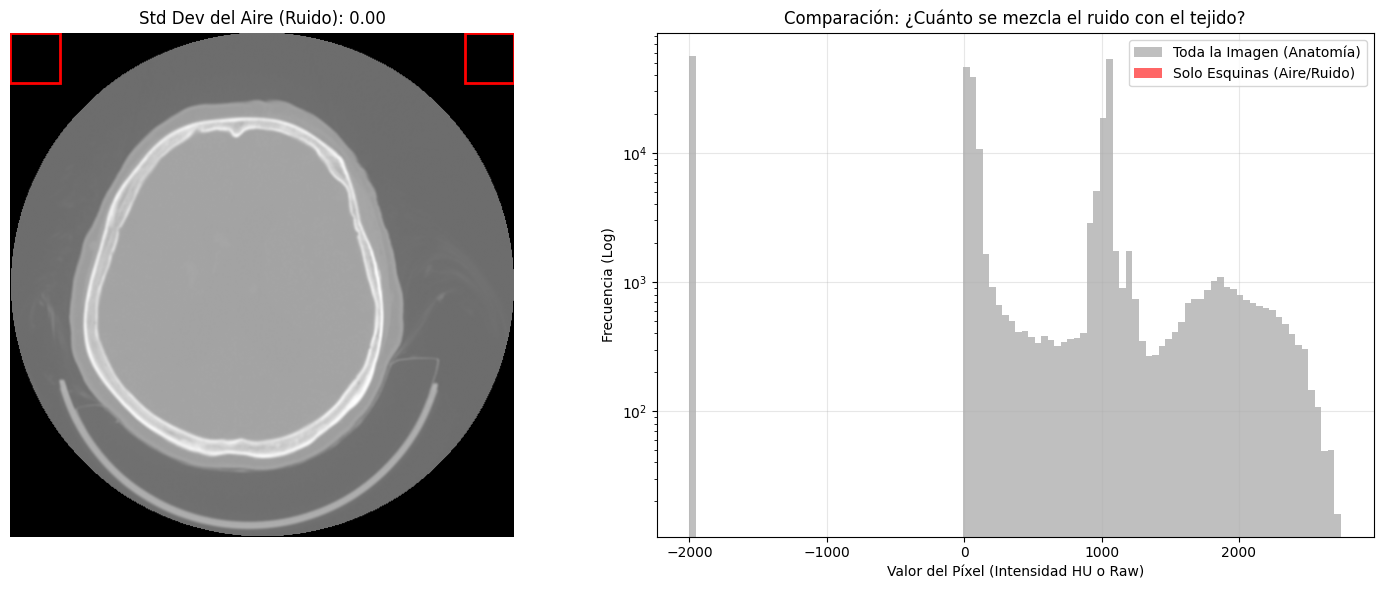

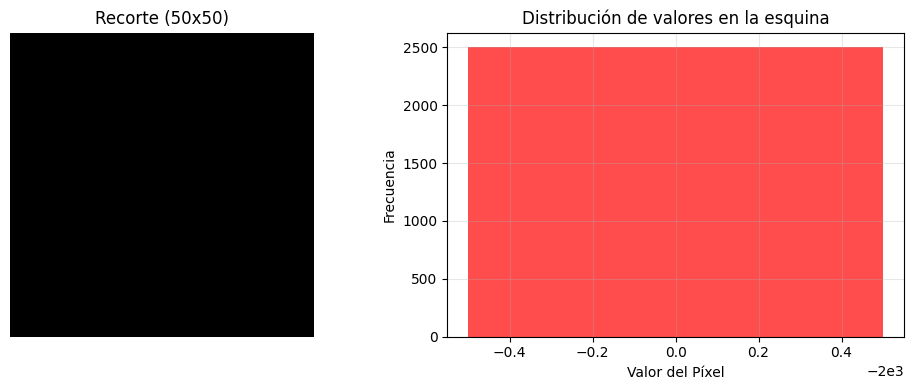

--- Estadísticas de la esquina ---
Min: -2000, Max: -2000
Valores únicos encontrados: [-2000]


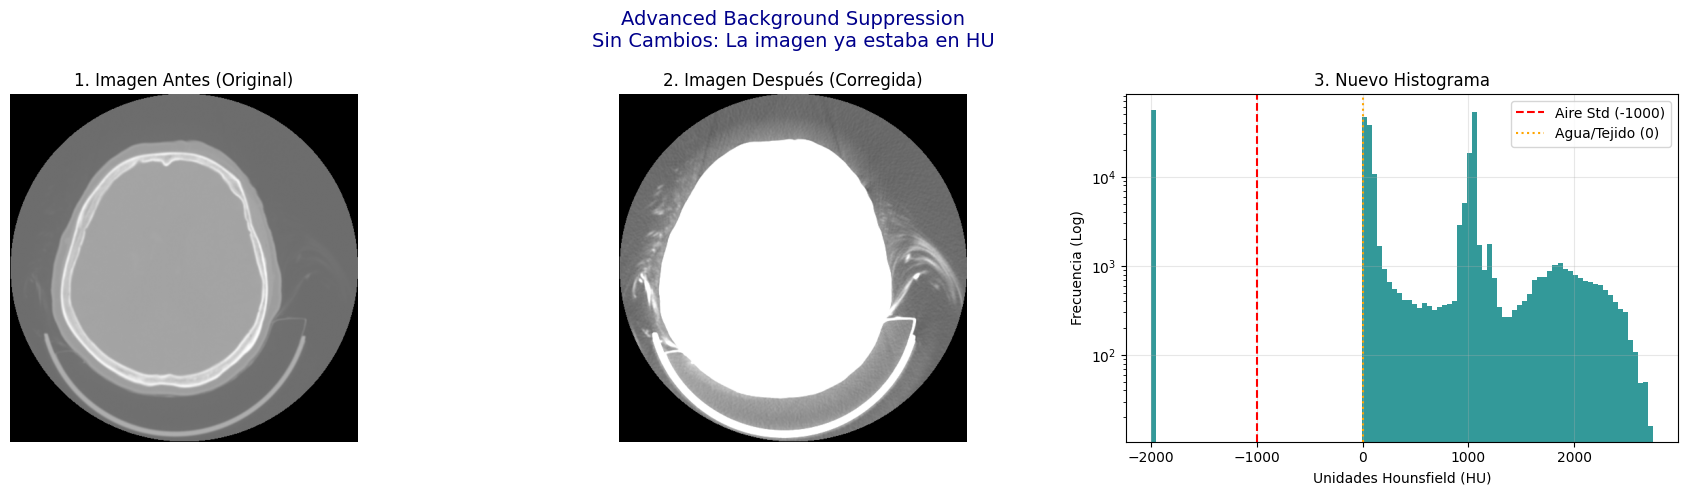

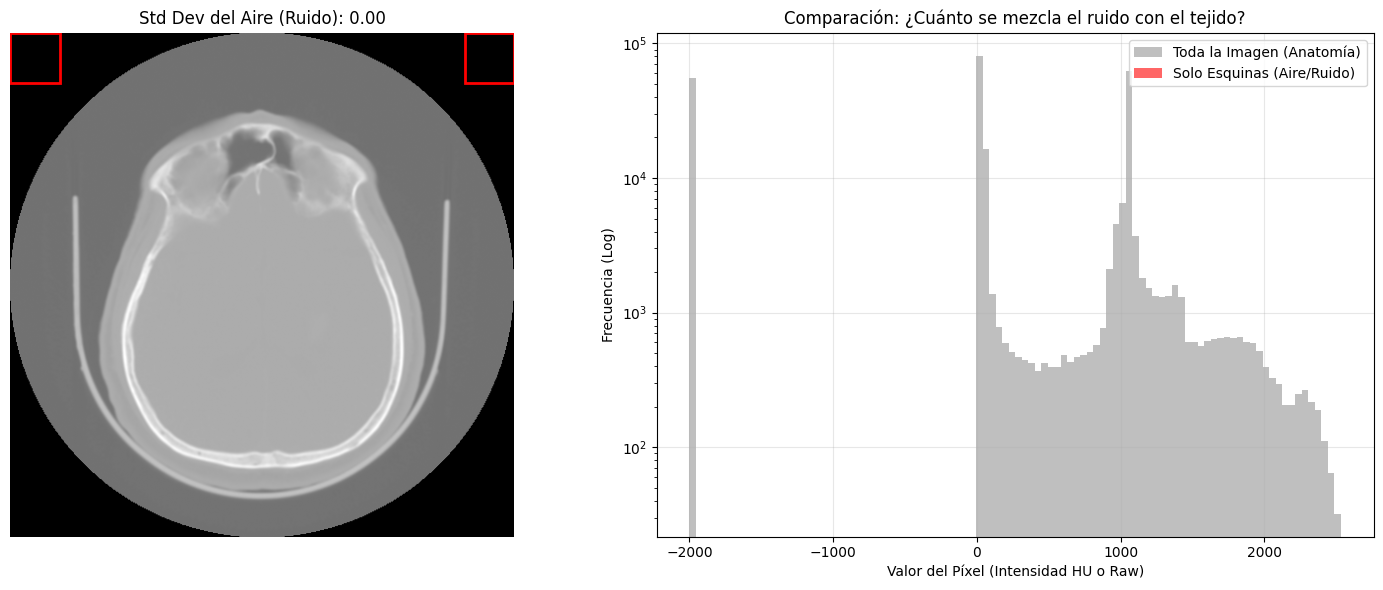

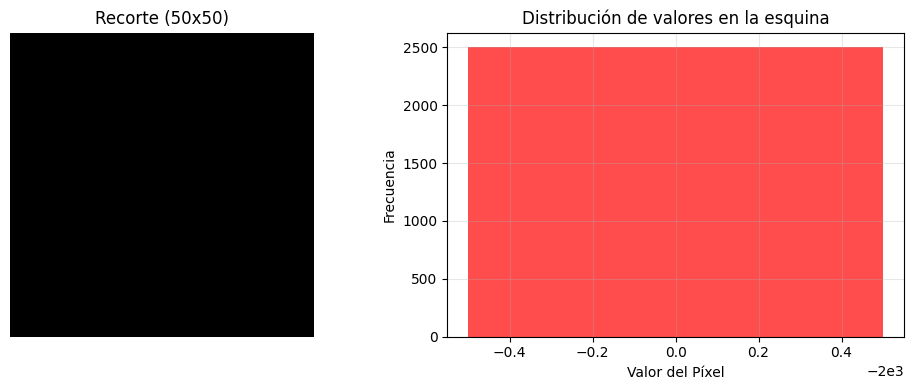

--- Estadísticas de la esquina ---
Min: -2000, Max: -2000
Valores únicos encontrados: [-2000]


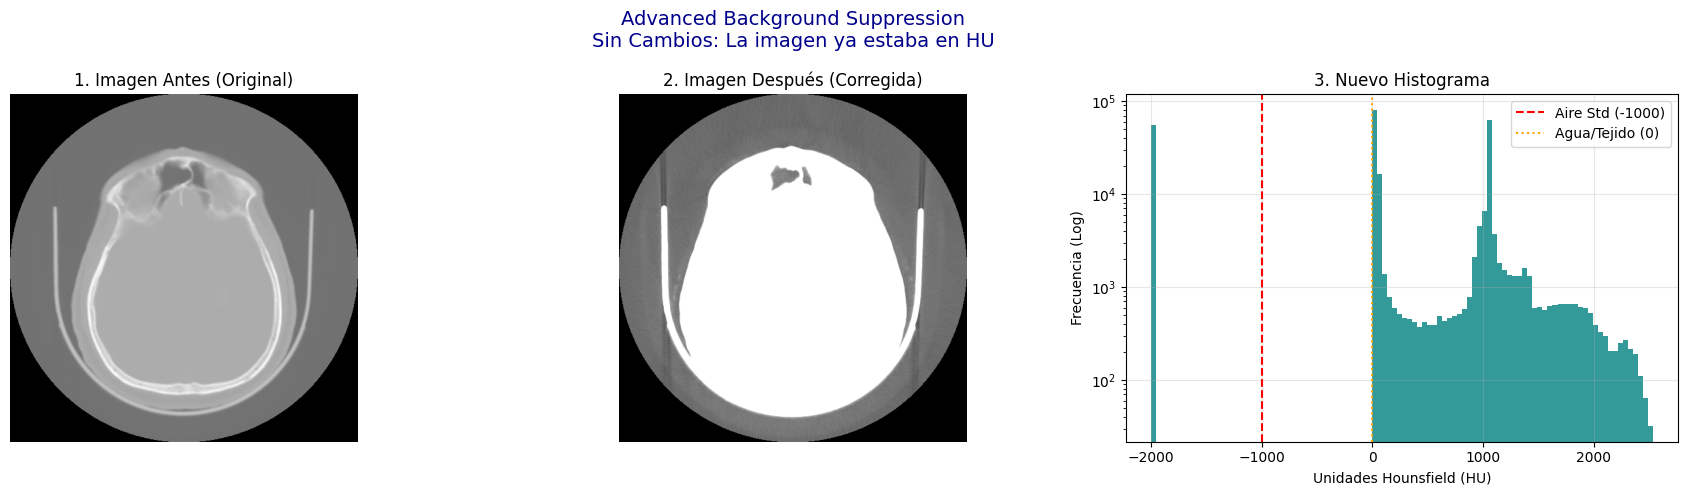

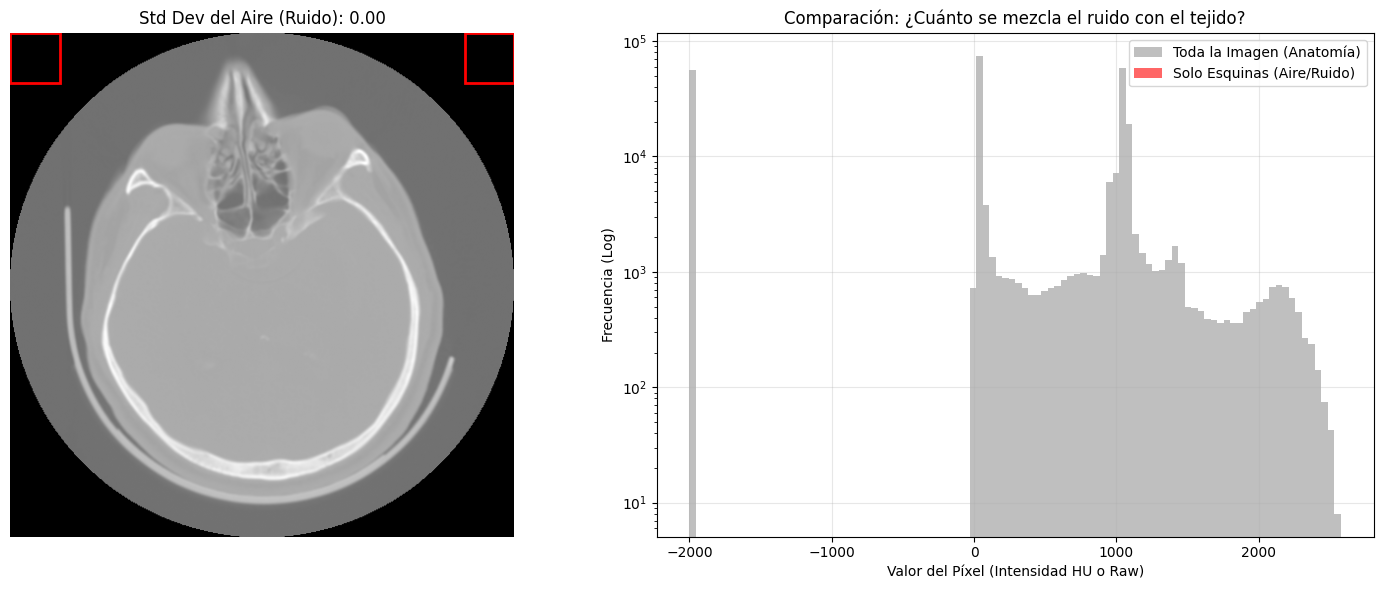

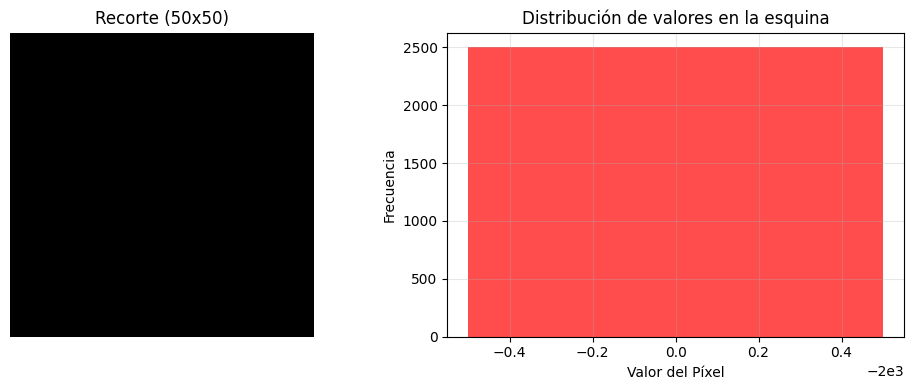

--- Estadísticas de la esquina ---
Min: -2000, Max: -2000
Valores únicos encontrados: [-2000]


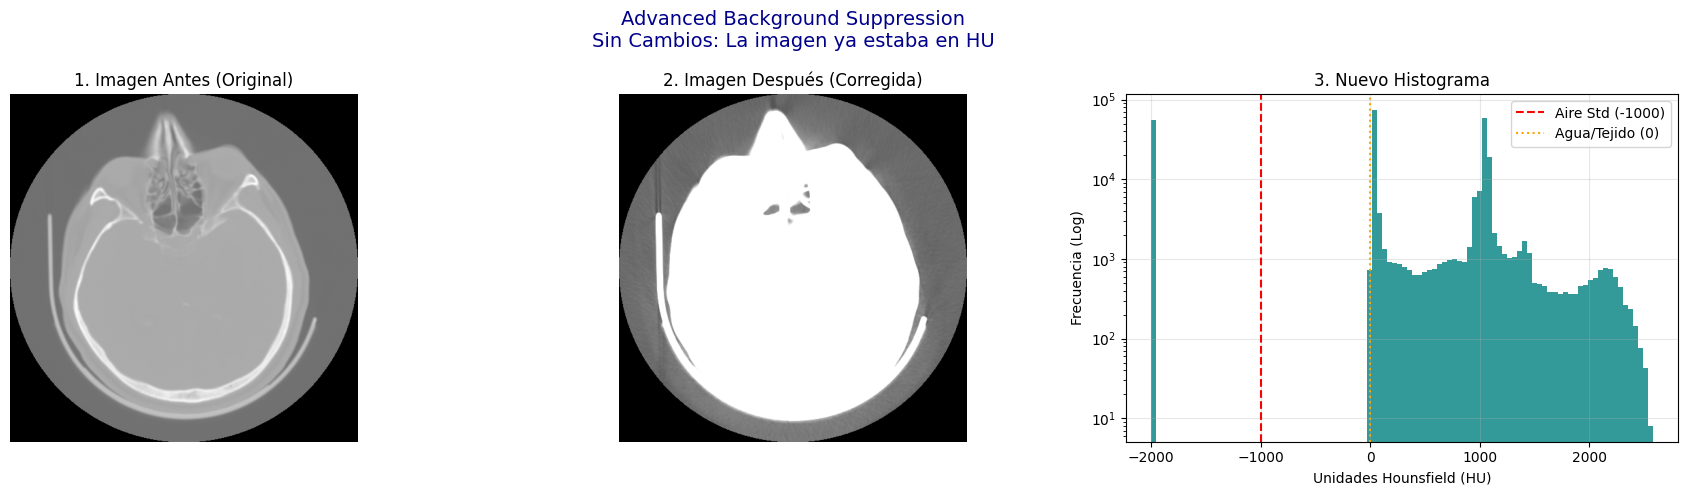

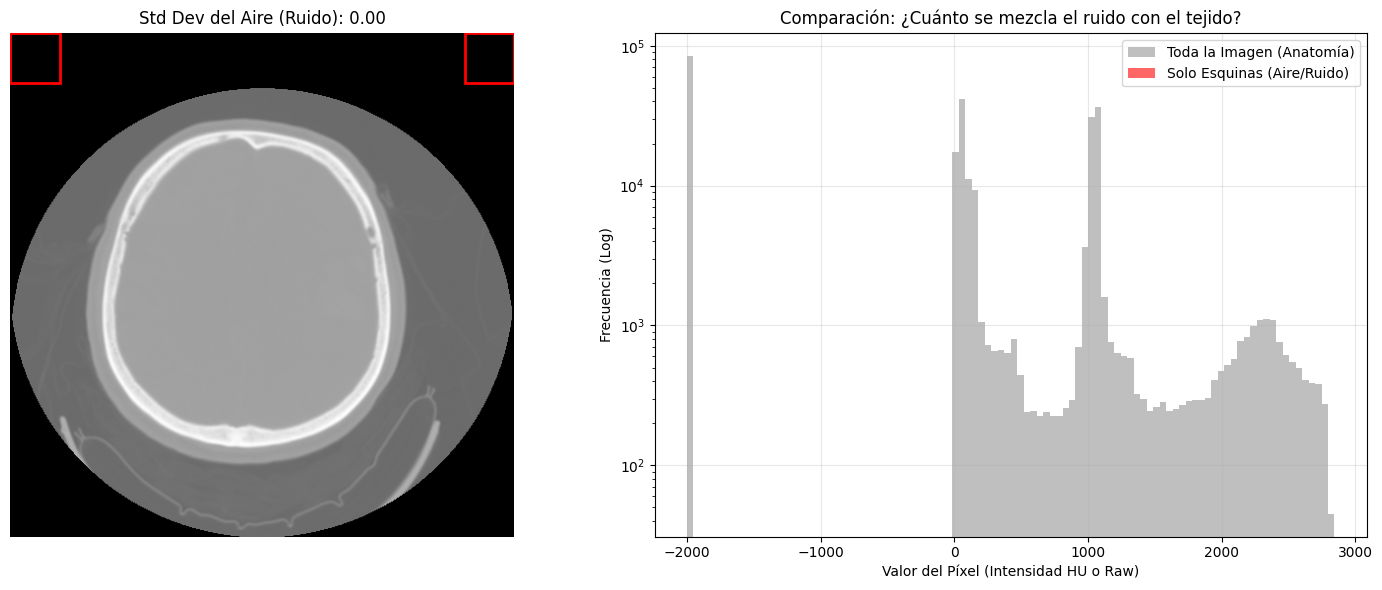

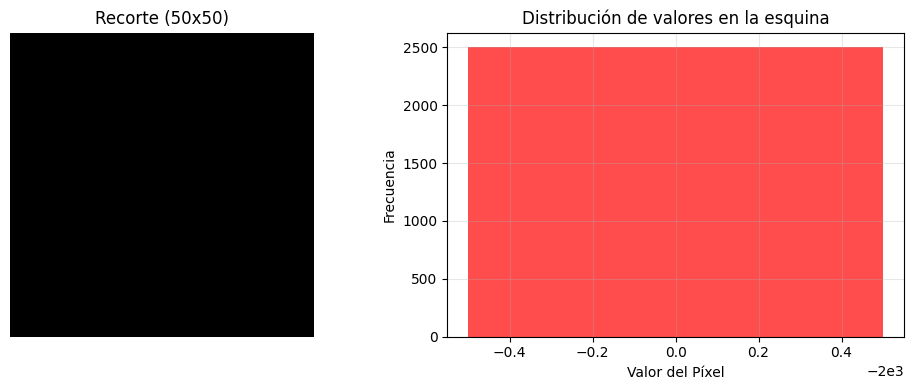

--- Estadísticas de la esquina ---
Min: -2000, Max: -2000
Valores únicos encontrados: [-2000]


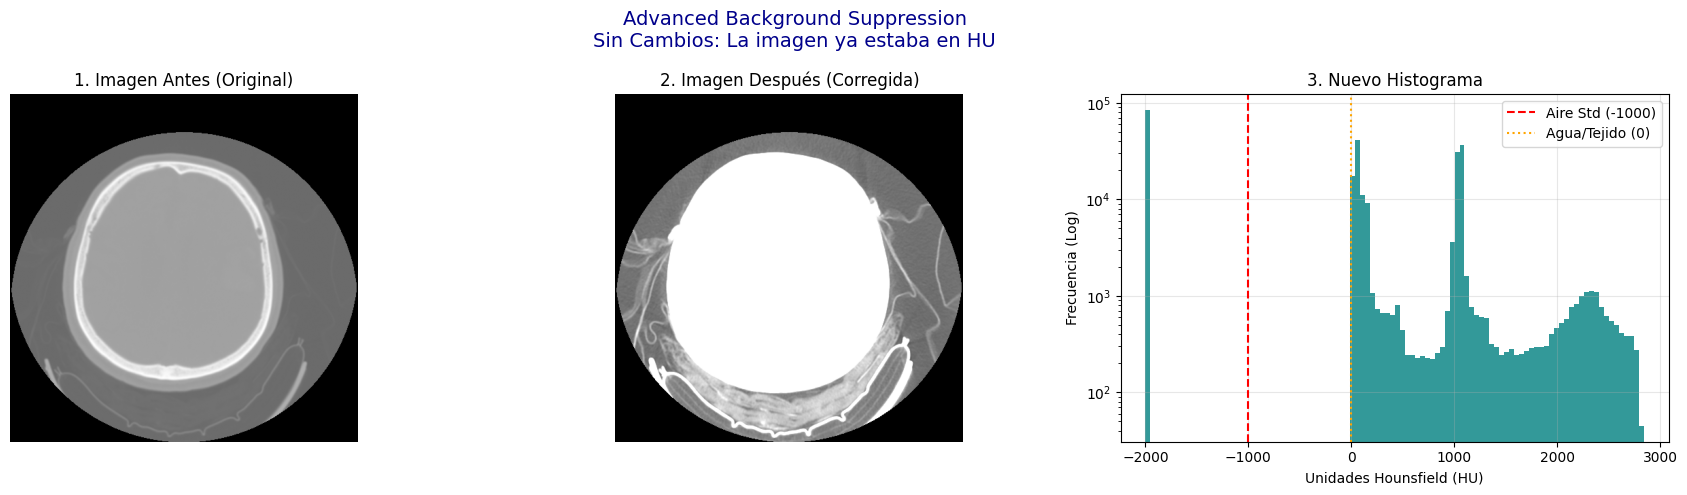

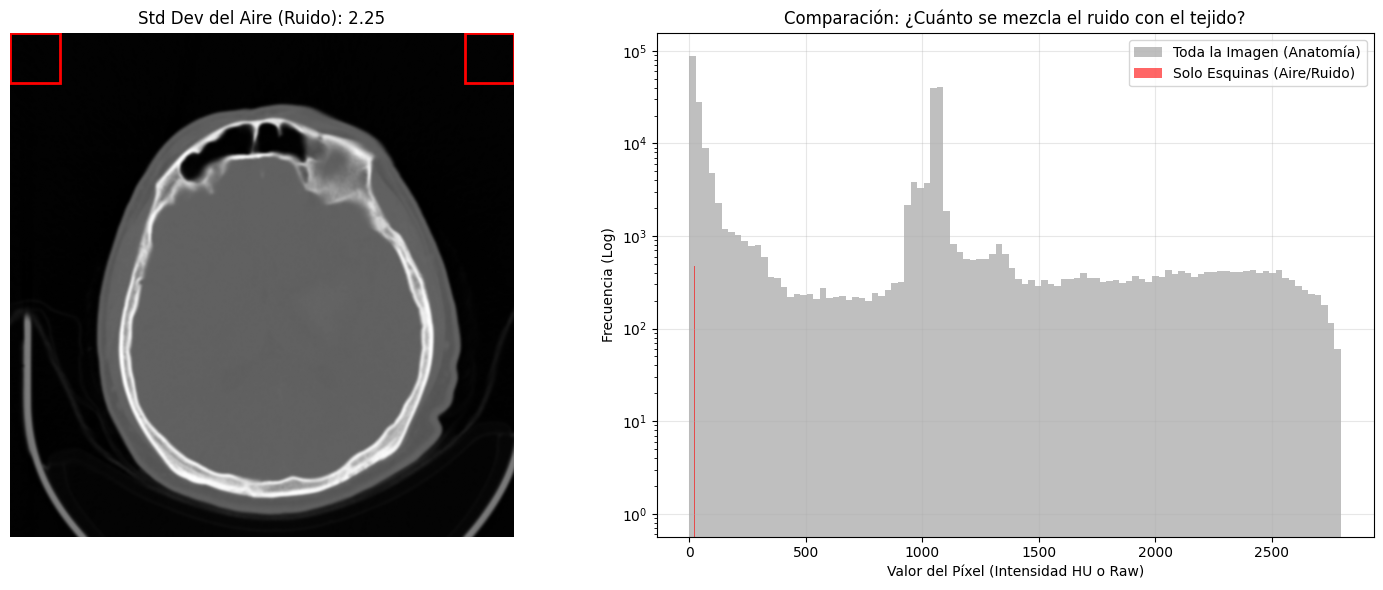

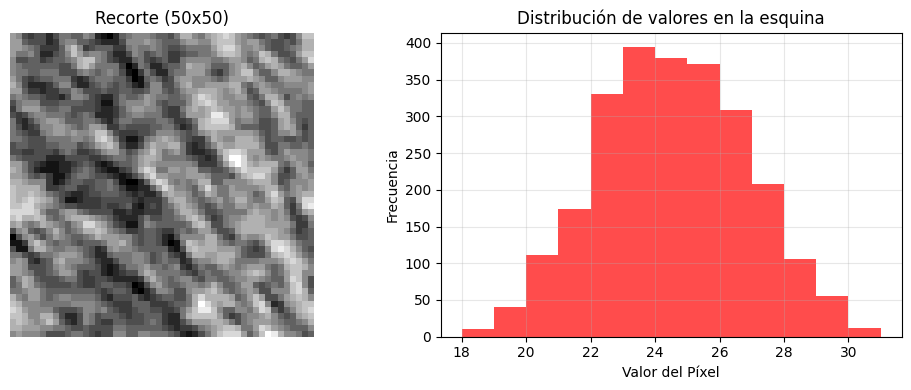

--- Estadísticas de la esquina ---
Min: 18, Max: 31
Valores únicos encontrados: [18 19 20 21 22 23 24 25 26 27 28 29 30 31]


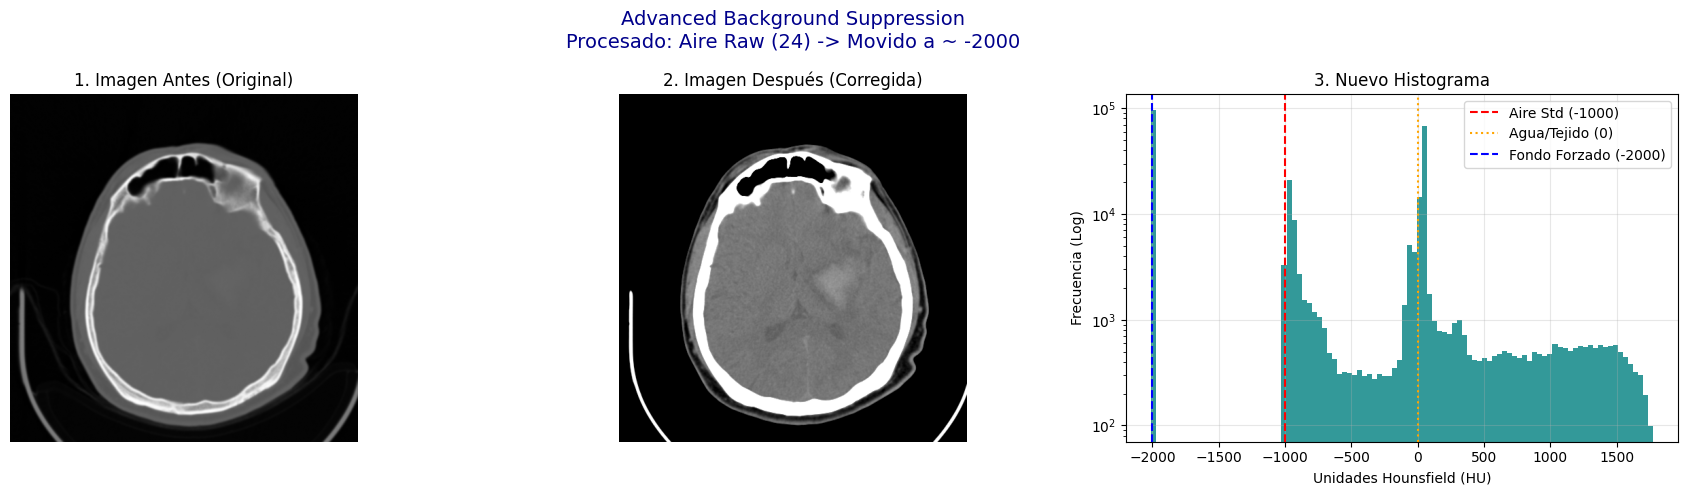

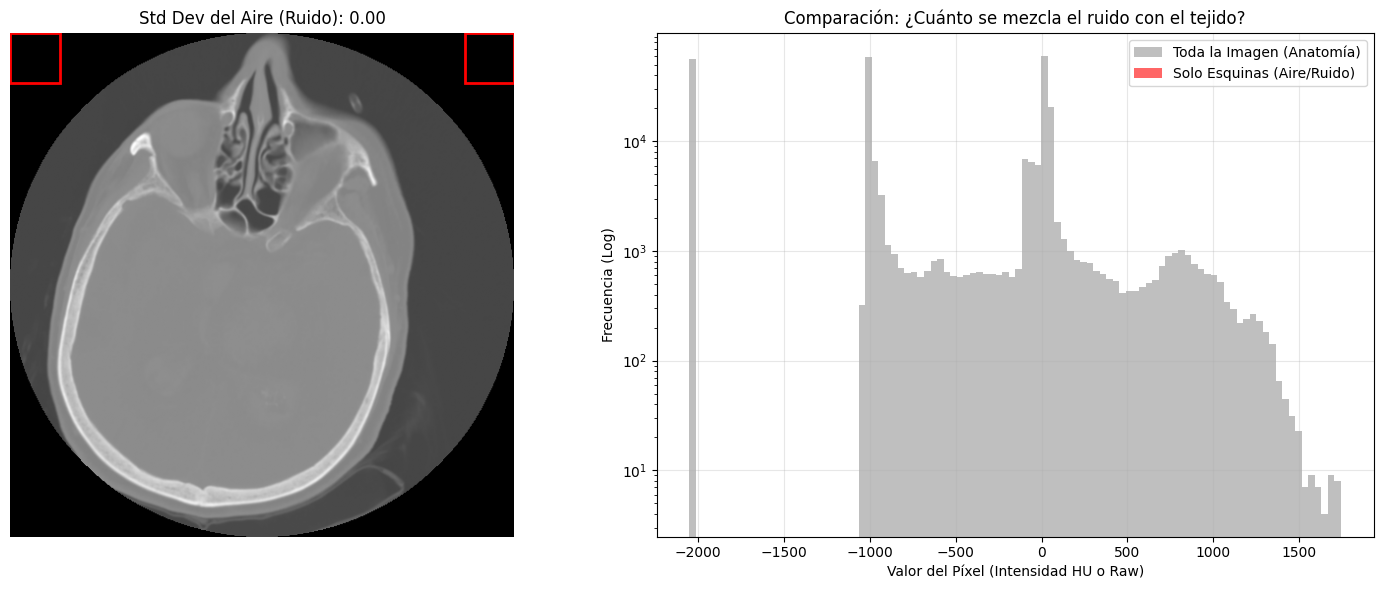

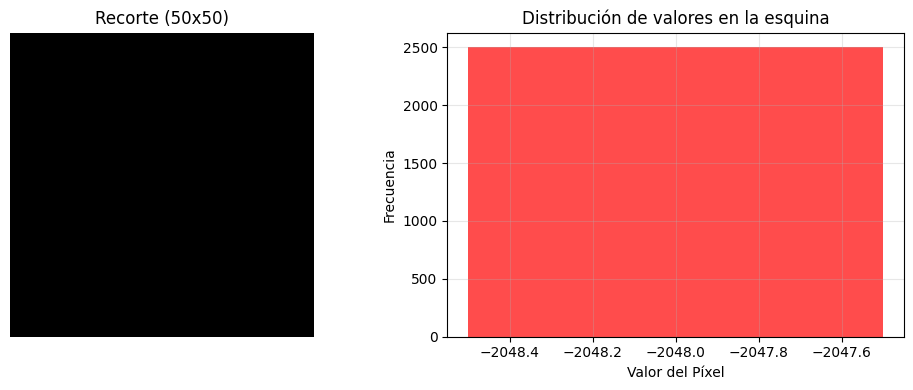

--- Estadísticas de la esquina ---
Min: -2048, Max: -2048
Valores únicos encontrados: [-2048]


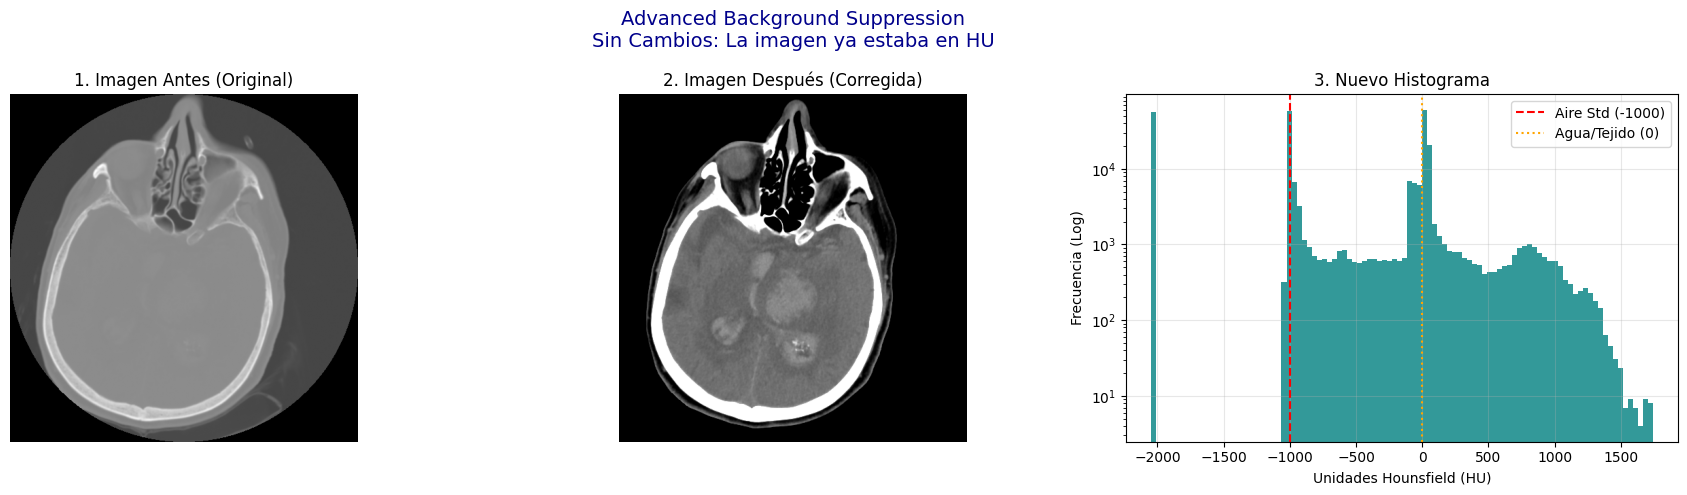

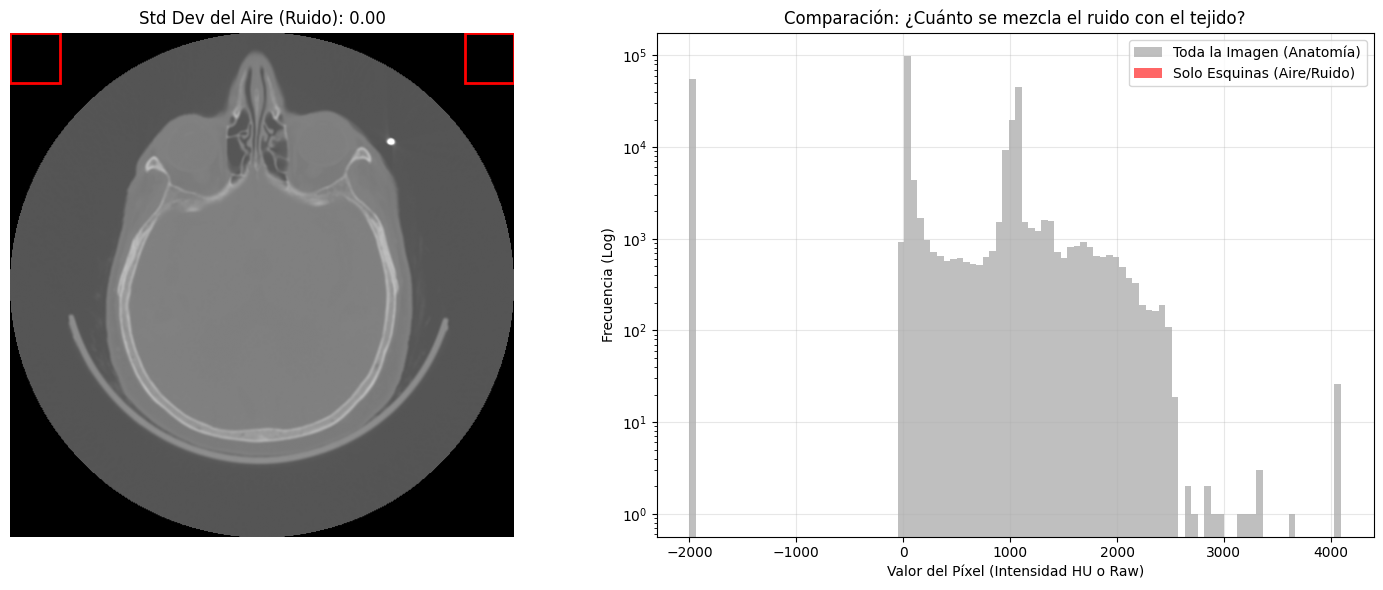

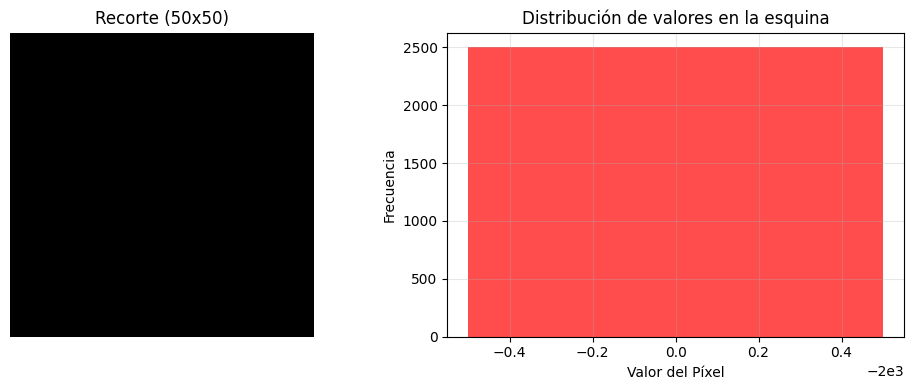

--- Estadísticas de la esquina ---
Min: -2000, Max: -2000
Valores únicos encontrados: [-2000]


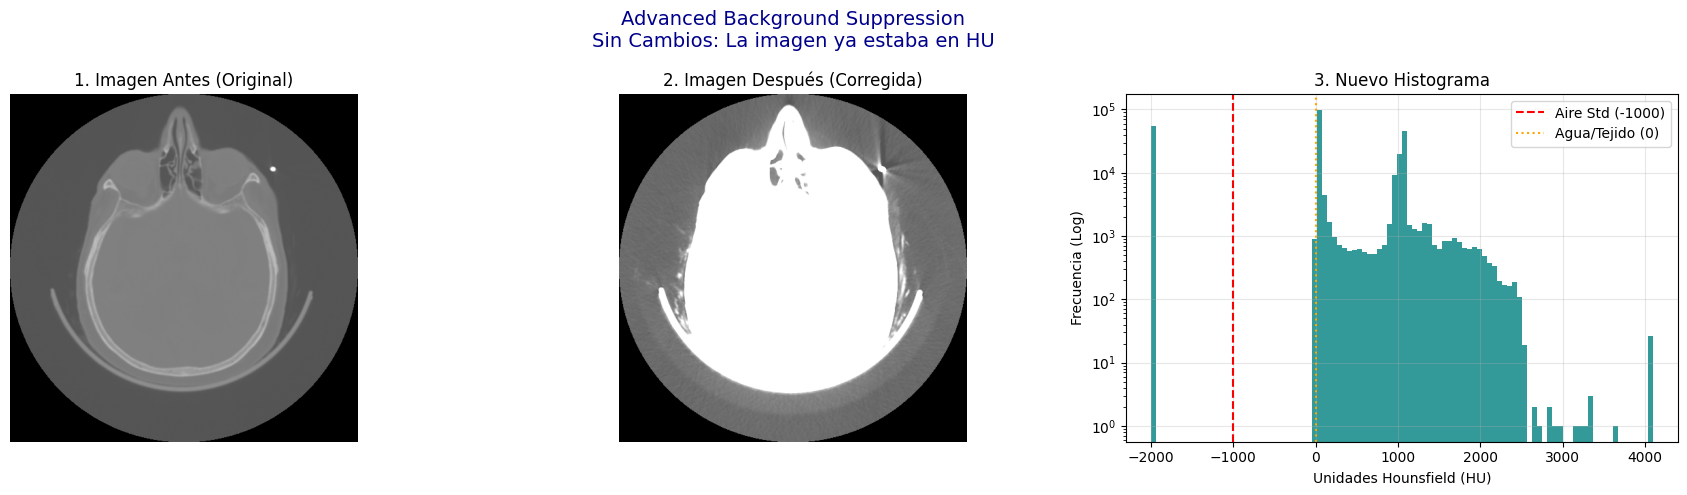

In [154]:
for i in range(10):
    analyze_noise_vs_content(subdataset['Bleeding'][i], corner_size=50)
    get_top_left_corner(subdataset['Bleeding'][i], size=50, histogram=True)
    advanced_background_suppression(subdataset['Bleeding'][i], corner_size=50)

In [152]:
processor = CTProcessor(subdataset['Normal'][0], corner_size=50)

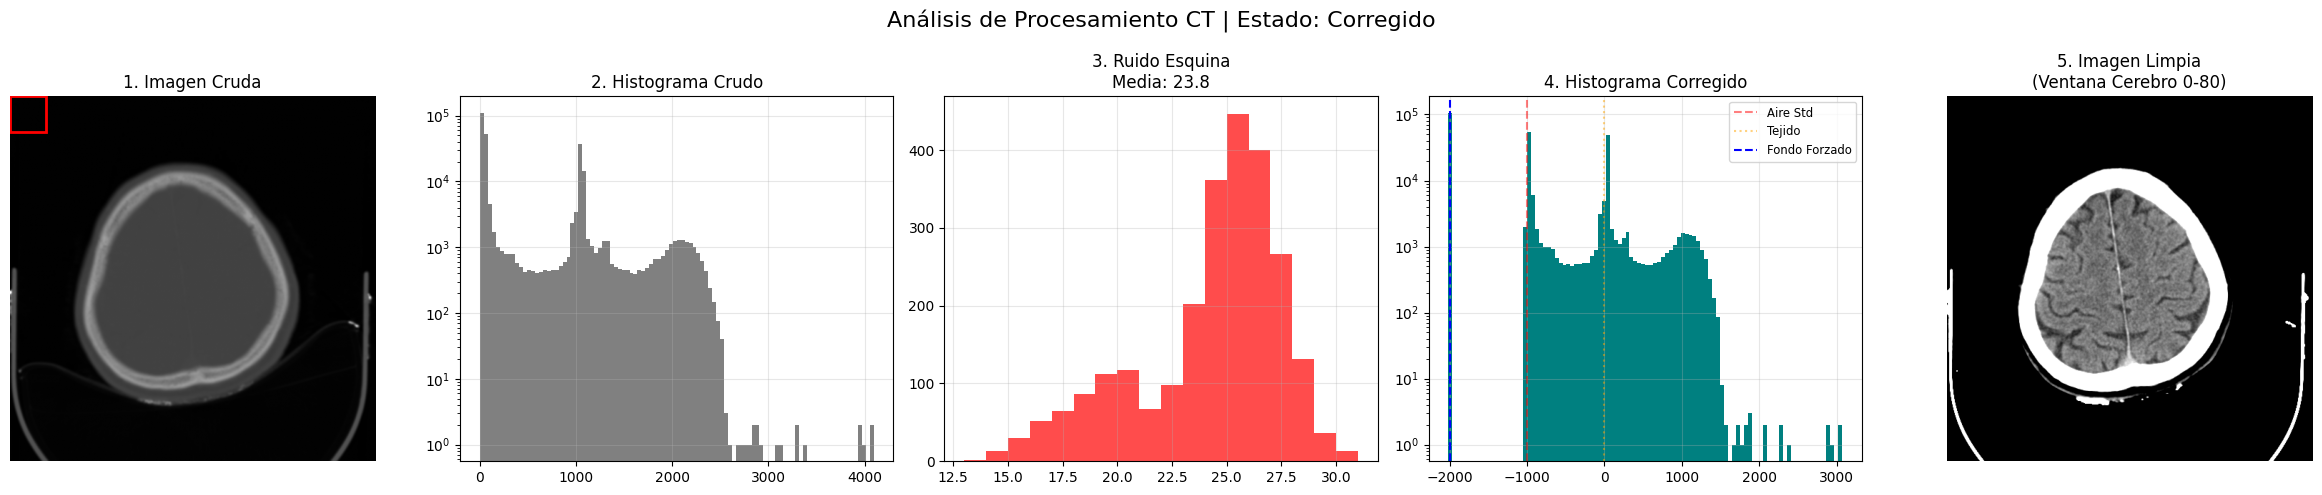

In [153]:
processor.plot()